In [5]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import interp1d
import time as _time

FILE_PATH = os.getcwd()
sys.path.append(os.path.join(FILE_PATH, '..'))
import plot_settings
plot_settings.apply()

COLORS    = plot_settings.colors()
DATA_DIR  = os.path.join(FILE_PATH, 'Multi_data')
DATA_FILE = os.path.join(DATA_DIR, '2_merged_data.txt')
DT        = 1.0

In [ ]:
# ── Load data ──────────────────────────────────────────────
data = pd.read_csv(DATA_FILE, sep=';', comment='%')
data['eta'] = -data['eta']

# Build OCV interpolator from data (same as battery models)
_s, _u = data['soc'].values, data['Ue'].values
_i = np.argsort(_s)
Ue_interp = interp1d(_s[_i], _u[_i], kind='linear', fill_value='extrapolate')

print(f"  {len(data)} pts, {data['trajectory'].nunique()} trajectories")

# ── Build trajectories ─────────────────────────────────────
def prepare_data(data):
    trajs = []
    for _, grp in data.sort_values(['trajectory', 't']).groupby('trajectory'):
        grp = grp.reset_index(drop=True)
        I_val, u_val = float(grp['I'].iloc[0]), float(grp['u'].iloc[0])
        soc_arr = grp['soc'].values.astype(np.float32)
        trajs.append(dict(
            I       = I_val,
            u       = u_val,
            soc0    = float(grp['soc'].iloc[0]),
            T       = len(grp),
            t       = np.arange(len(grp)) * DT,
            i_profile = np.full(len(grp), I_val, dtype=np.float32),
            ocv     = Ue_interp(soc_arr),          # OCV from interp, same as Ue
            V_true  = grp['V'].values.astype(np.float32),
            soc_true = soc_arr,
            eta      = grp['eta'].values.astype(np.float32),
        ))
    return trajs

trajs = prepare_data(data)
print(f"  {len(trajs)} trajectories prepared")

  415557 pts, 248 trajectories
  248 trajectories prepared


In [7]:
# --- ODE solver---
def simulate_ode(t, i_profile, ocv, p=params):
    """
    t          : 1-D time array (s)
    i_profile  : 1-D current array, same length as t
    ocv        : 1-D open circuit voltage array, same length as t
    """
    def current(t_scalar):
        return np.interp(t_scalar, t, i_profile)

    def dU1(u, t_s):               # RC voltage ODE
        return -u / (p['R1'] * p['C1']) + current(t_s) / p['C1']

    def dSOC(z, t_s):              # SOC ODE
        return -current(t_s) / p['Q']

    U1  = scipy.integrate.odeint(dU1,  0.0, t, args=()).flatten()
    soc = scipy.integrate.odeint(dSOC, 1.0, t, args=()).flatten()

    V   = ocv - i_profile * p['R0'] - U1
    return V, soc, U1

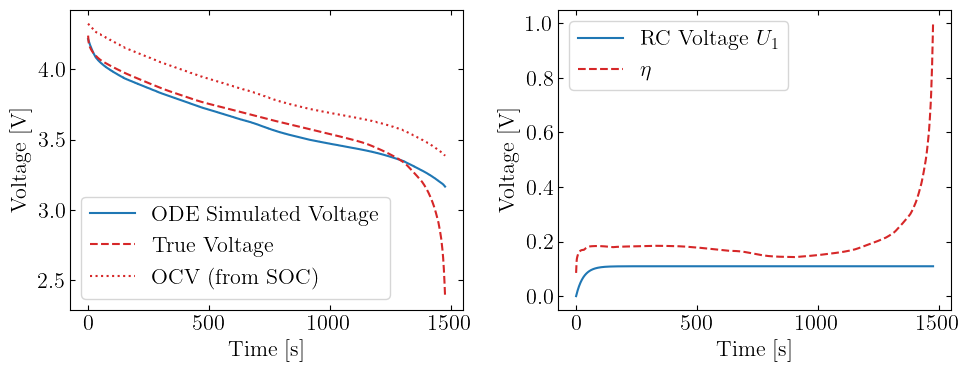

In [18]:
tr = trajs[0]

params = dict(
    R0=0.01,
    R1=0.01,
    C1=3000,
    Q=17921.57581,       # match Q0 from the battery models
)

V, soc, U1 = simulate_ode(tr['t'], tr['i_profile'], tr['ocv'], p=params)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(tr['t'], V, color=COLORS[0], label='ODE Simulated Voltage')
axes[0].plot(tr['t'], tr['V_true'], color=COLORS[1], linestyle='--', label='True Voltage')
axes[0].plot(tr['t'], tr['ocv'], color=COLORS[1], linestyle=':', label='OCV (from SOC)')
axes[0].set_xlabel('Time [s]'); axes[0].set_ylabel('Voltage [V]'); axes[0].legend()

axes[1].plot(tr['t'], U1, color=COLORS[0], label=r'RC Voltage $U_1$')
axes[1].plot(tr['t'], tr['eta'], color=COLORS[1], linestyle='--', label=r'$\eta$')
axes[1].set_xlabel('Time [s]'); axes[1].set_ylabel('Voltage [V]'); axes[1].legend()
plt.tight_layout()
# plt.savefig(os.path.join(FILE_PATH, 'nodes_figs', 'ecm_ode.pdf'), bbox_inches='tight')